Imports

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

Carga del hotel 3

In [ ]:
DATA_PROC_DIR = Path(r"C:\Users\jorge gonzalez\Documents\TFG\Proyecto\data\processed")
FIGS_DIR      = Path(r"C:\Users\jorge gonzalez\Documents\TFG\Proyecto\reports\figuras")
FIGS_DIR.mkdir(parents=True, exist_ok=True)
 
# %% Carga y filtro Hotel 3
df_hotel = pd.read_parquet(DATA_PROC_DIR / "livvo_day_hotel_final.parquet")
df_h3 = df_hotel[df_hotel["codigo_hotel"] == "HOTEL_3"].copy()
df_h3.head()

,date,codigo_hotel,roomnights,bednights,neto,stock,ocup_total,ADR
2,2023-01-01,HOTEL_3,154,328,41940.92,251,0.613546,272.343636
5,2023-01-02,HOTEL_3,164,347,41479.70,251,0.653386,252.925000
8,2023-01-03,HOTEL_3,159,335,25886.08,251,0.633466,162.805535
11,2023-01-04,HOTEL_3,153,313,23733.26,251,0.609562,155.119346
14,2023-01-05,HOTEL_3,170,345,25345.60,251,0.677291,149.091765


Información general

In [3]:
df_h3.info()
df_h3.describe()
df_h3.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 1085 entries, 2 to 3037
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1085 non-null   datetime64[us]
 1   codigo_hotel  1085 non-null   object        
 2   roomnights    1085 non-null   int64         
 3   bednights     1085 non-null   int64         
 4   neto          1085 non-null   float64       
 5   stock         1085 non-null   int64         
 6   ocup_total    1085 non-null   float64       
 7   ADR           1085 non-null   float64       
dtypes: datetime64[us](1), float64(3), int64(3), object(1)
memory usage: 76.3+ KB


date            0
codigo_hotel    0
roomnights      0
bednights       0
neto            0
stock           0
ocup_total      0
ADR             0
dtype: int64

Rango Temporal

In [4]:
df_h3["date"].min(), df_h3["date"].max(), len(df_h3)


(Timestamp('2023-01-01 00:00:00'), Timestamp('2025-12-23 00:00:00'), 1085)

Visualización básica

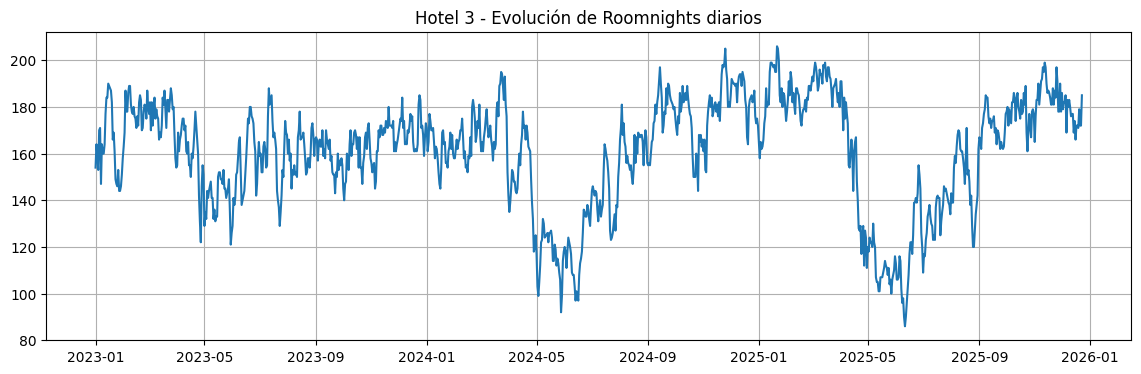

In [5]:
plt.figure(figsize=(14, 4))
plt.plot(df_h3["date"], df_h3["roomnights"], label="Roomnights")
plt.title("Hotel 3 - Evolución de Roomnights diarios")
plt.grid(True)
plt.show()

Ocupación

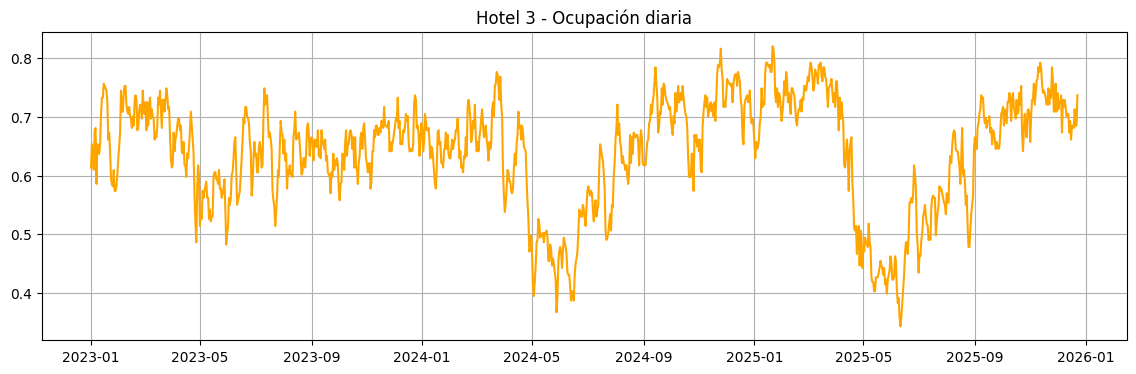

In [6]:
plt.figure(figsize=(14, 4))
plt.plot(df_h3["date"], df_h3["ocup_total"], color="orange")
plt.title("Hotel 3 - Ocupación diaria")
plt.grid(True)
plt.show()

ADR

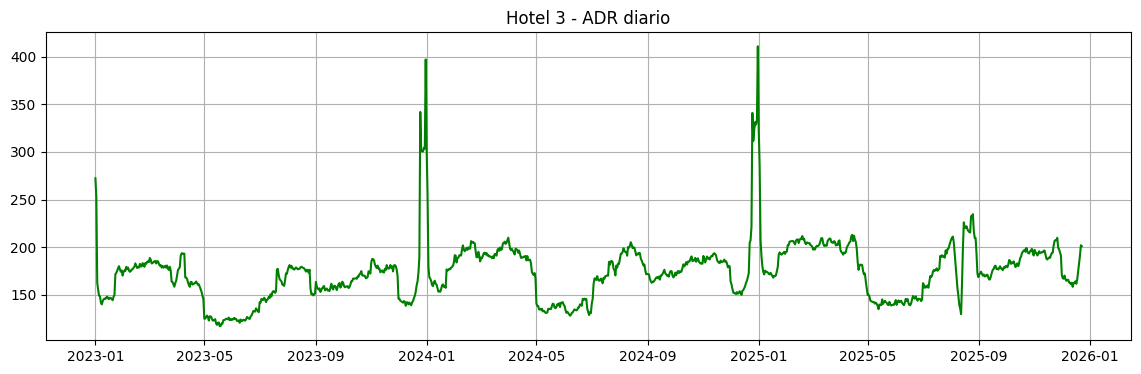

In [7]:
plt.figure(figsize=(14, 4))
plt.plot(df_h3["date"], df_h3["ADR"], color="green")
plt.title("Hotel 3 - ADR diario")
plt.grid(True)
plt.show()

Distribución de variables clave

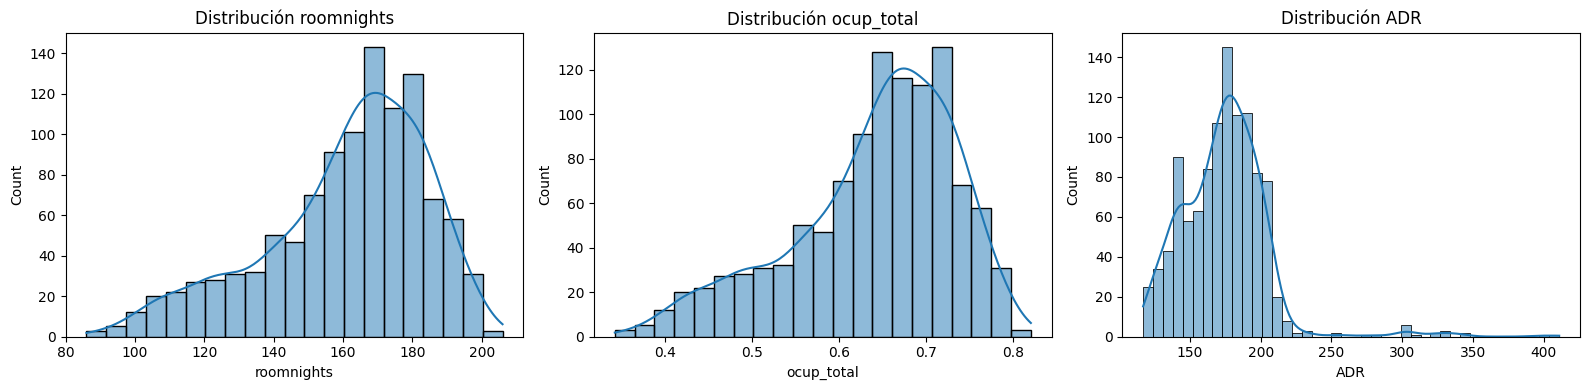

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
 
sns.histplot(df_h3["roomnights"], kde=True, ax=axes[0])
axes[0].set_title("Distribución roomnights")
 
sns.histplot(df_h3["ocup_total"], kde=True, ax=axes[1])
axes[1].set_title("Distribución ocup_total")
 
sns.histplot(df_h3["ADR"], kde=True, ax=axes[2])
axes[2].set_title("Distribución ADR")
 
plt.tight_layout()
plt.show()

Estacionalidad visual (mensual)

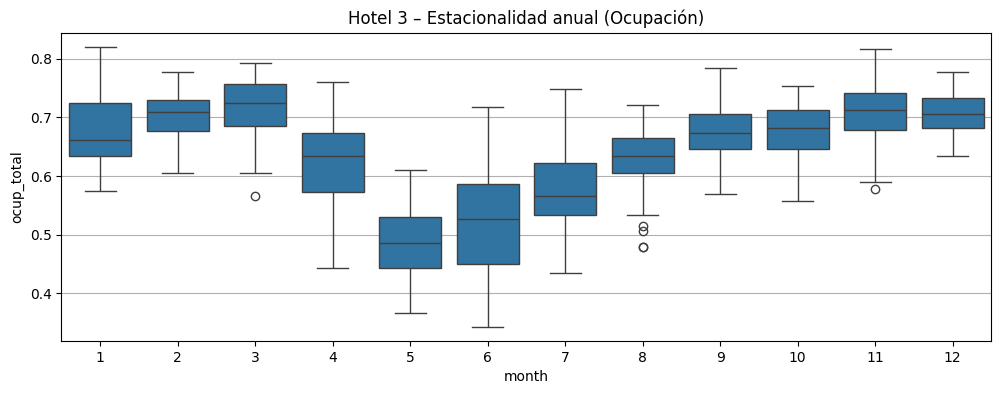

In [9]:
df_month = df_h3.copy()
df_month["month"] = df_month["date"].dt.month
 
plt.figure(figsize=(12, 4))
sns.boxplot(data=df_month, x="month", y="ocup_total")
plt.title("Hotel 3 – Estacionalidad anual (Ocupación)")
plt.grid(True, axis="y")
plt.show()

Estacionalidad semanal (día de la semana)

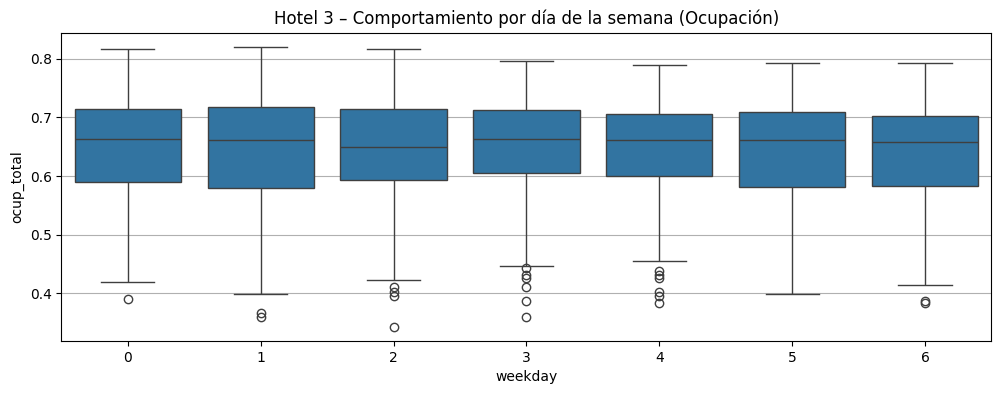

In [10]:
df_week = df_h3.copy()
df_week["weekday"] = df_week["date"].dt.dayofweek
 
plt.figure(figsize=(12, 4))
sns.boxplot(data=df_week, x="weekday", y="ocup_total")
plt.title("Hotel 3 – Comportamiento por día de la semana (Ocupación)")
plt.grid(True, axis="y")
plt.show()
 

Matriz de correlación

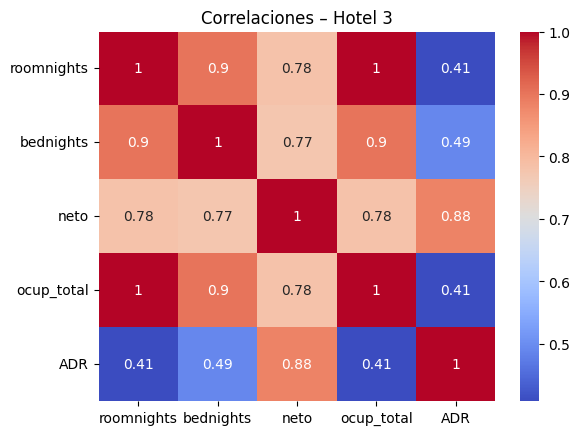

In [11]:
sns.heatmap(
    df_h3[["roomnights", "bednights", "neto", "ocup_total", "ADR"]].corr(),
    annot=True, cmap="coolwarm"
)
plt.title("Correlaciones – Hotel 3")
plt.show()

Outliers en ocupación (IQR)

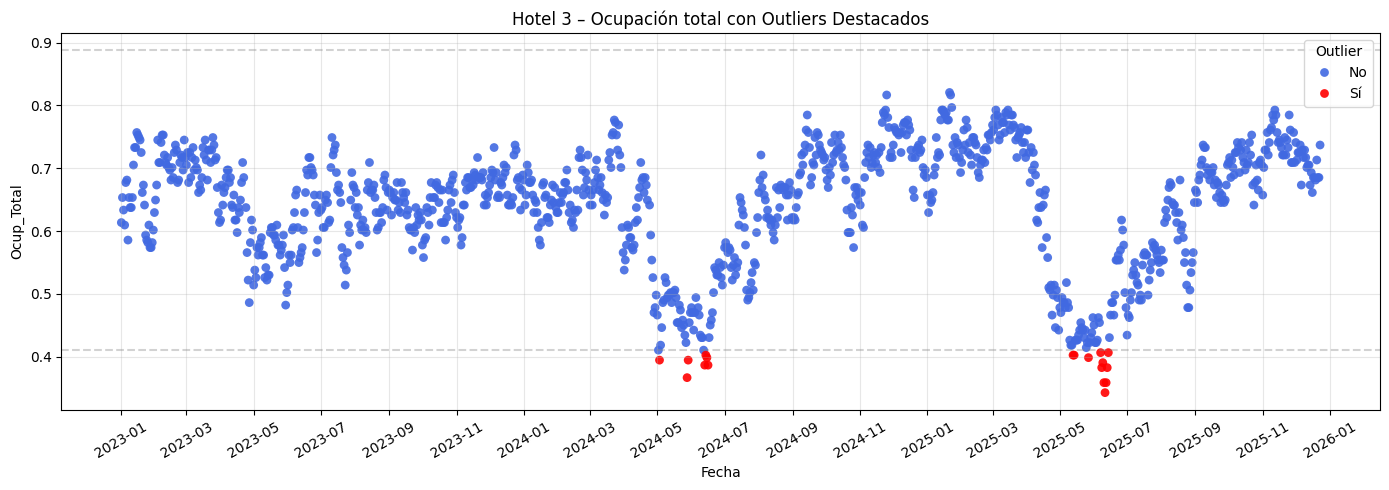

In [12]:
Q1 = df_h3["ocup_total"].quantile(0.25)
Q3 = df_h3["ocup_total"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
 
plot_df = df_h3.copy()
plot_df["is_outlier"]    = (plot_df["ocup_total"] < lower_bound) | (plot_df["ocup_total"] > upper_bound)
plot_df["outlier_label"] = plot_df["is_outlier"].map({False: "No", True: "Sí"})
hue_order = ["No", "Sí"]
palette   = {"No": "royalblue", "Sí": "red"}
 
plt.figure(figsize=(14, 5))
ax = sns.scatterplot(
    data=plot_df,
    x="date",
    y="ocup_total",
    hue="outlier_label",
    hue_order=hue_order,
    palette=palette,
    s=40,
    alpha=0.9,
    edgecolor="none"
)
 
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=30)
 
plt.axhline(lower_bound, color="gray", linestyle="--", alpha=0.35)
plt.axhline(upper_bound, color="gray", linestyle="--", alpha=0.35)
 
plt.title("Hotel 3 – Ocupación total con Outliers Destacados")
plt.xlabel("Fecha")
plt.ylabel("Ocup_Total")
plt.grid(True, alpha=0.3)
plt.legend(title="Outlier", loc="best")
plt.tight_layout()
 
plt.show()

Heatmap tipo calendario (ocupación diaria)

C:\Users\jorge gonzalez\AppData\Local\Temp\ipykernel_95808\3516601736.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.97])


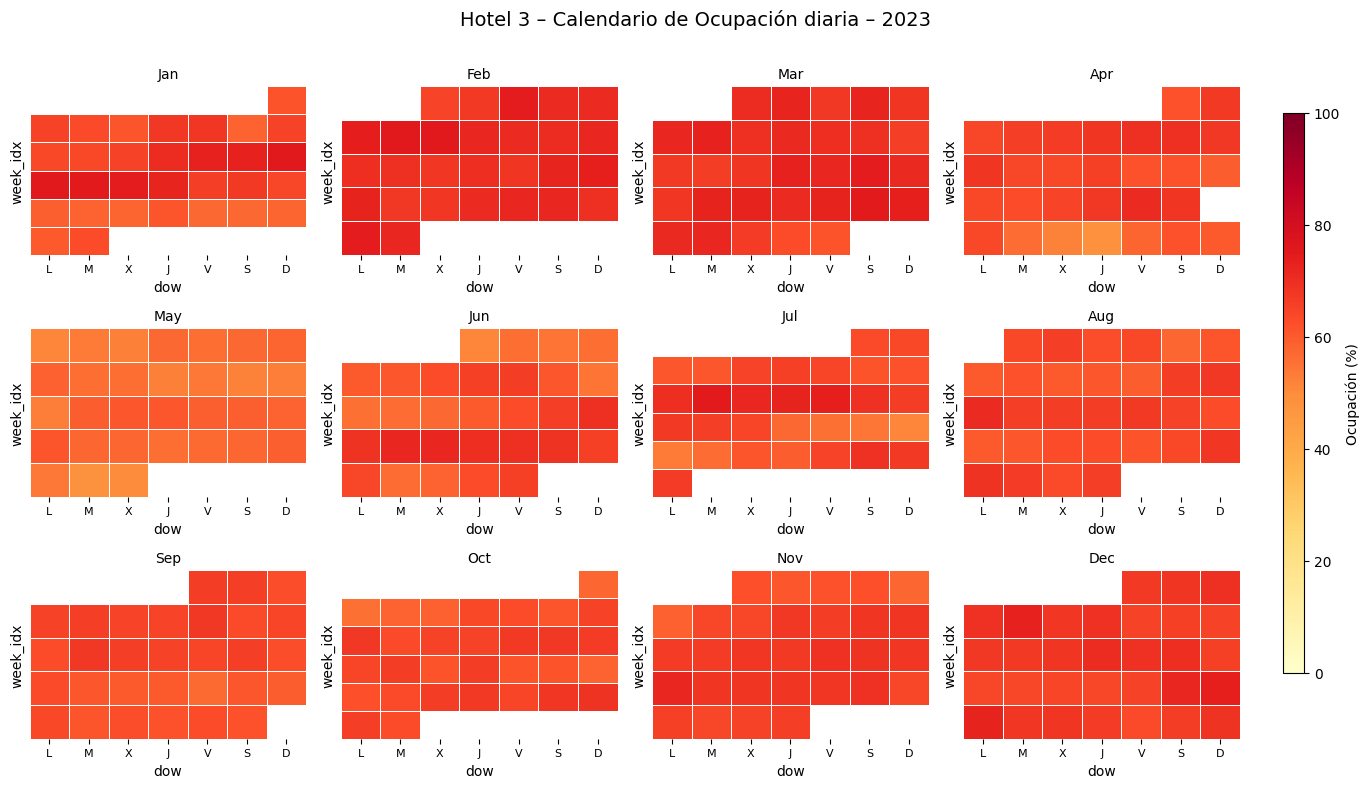

C:\Users\jorge gonzalez\AppData\Local\Temp\ipykernel_95808\3516601736.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.97])


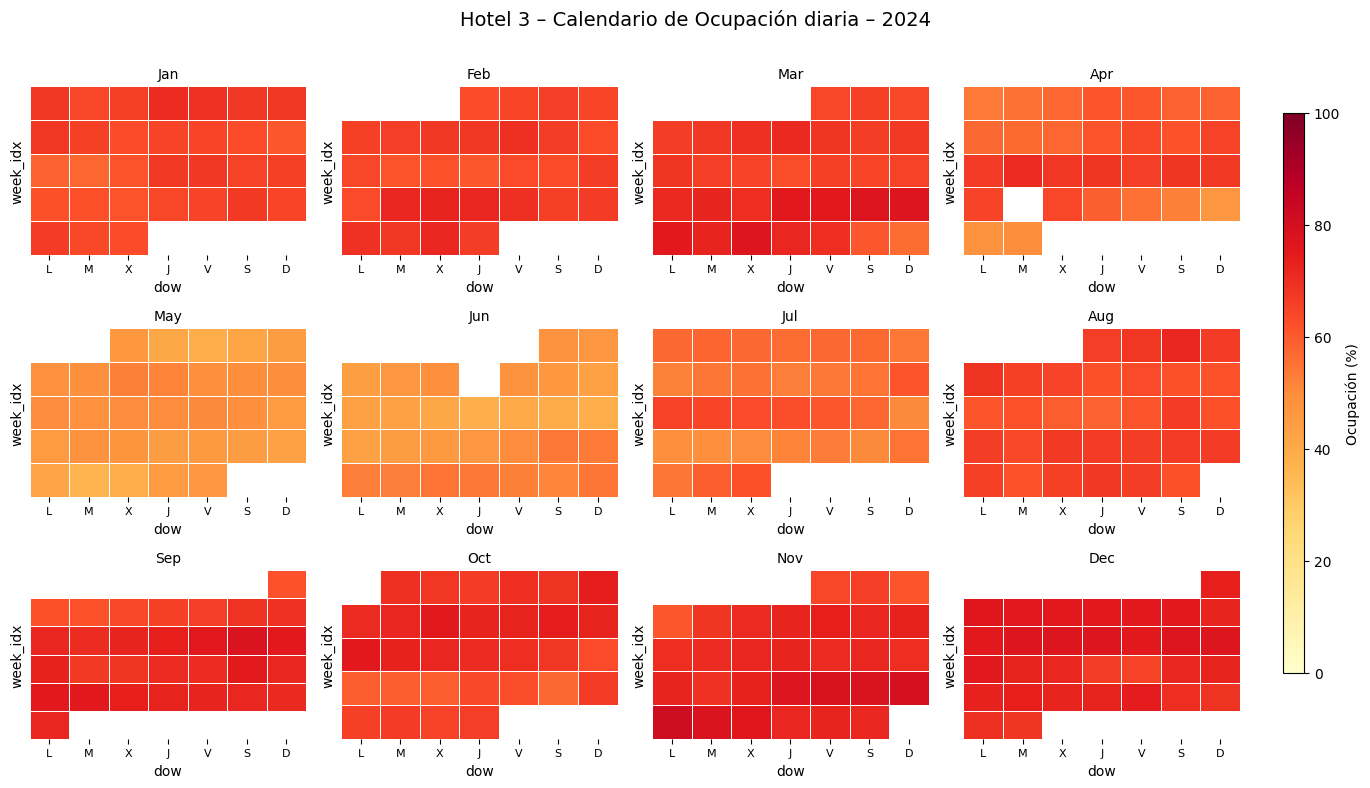

C:\Users\jorge gonzalez\AppData\Local\Temp\ipykernel_95808\3516601736.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.97])


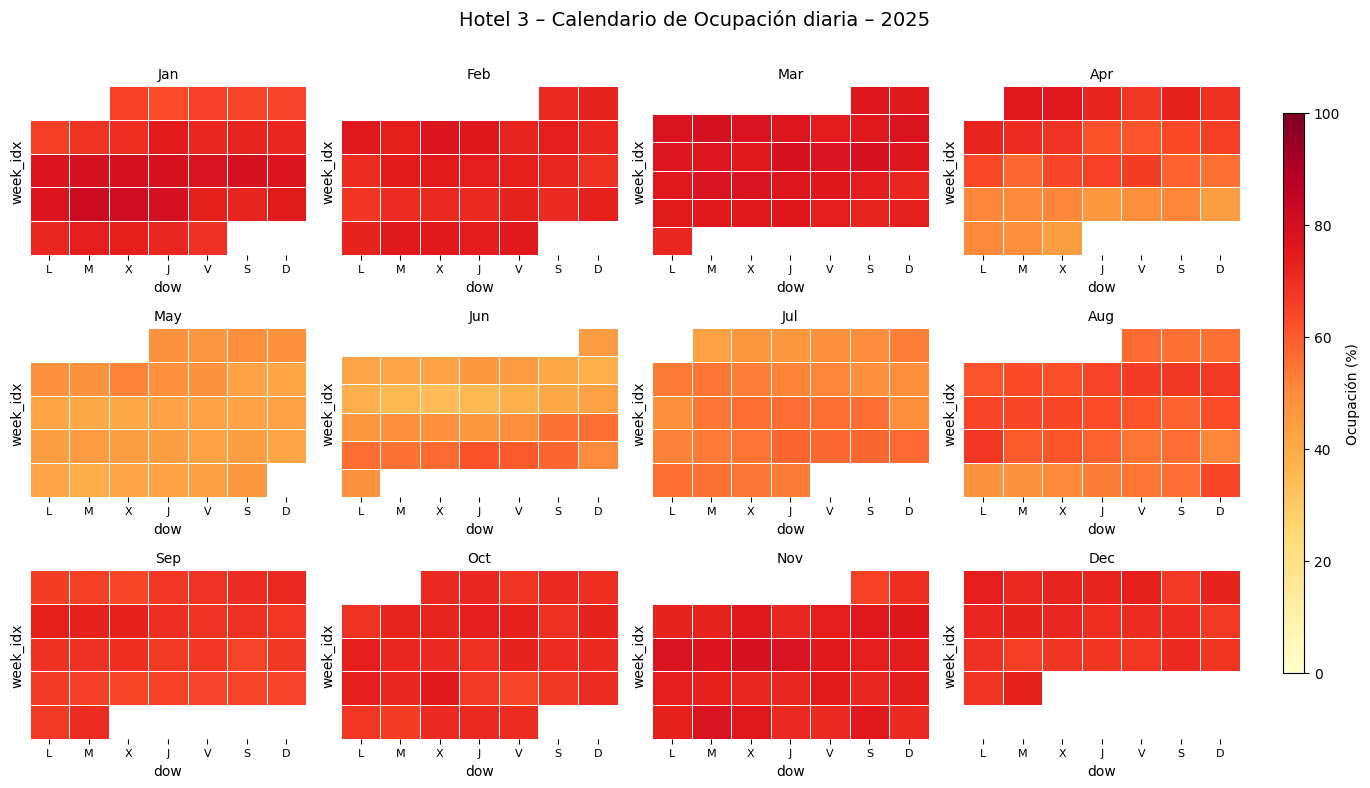

In [13]:
def month_calendar_heatmap(df_mes: pd.DataFrame, year: int, month: int, ax, cmap="YlOrRd"):
    """
    Dibuja el heatmap mensual con ocupación diaria partiendo de 'ocup_total'.
    Si 'ocup_total' viene en 0–1, la convierte a %; si viene en 0–100, la deja igual.
    """
    m = df_mes[["date", "ocup_total"]].copy()
    if m["ocup_total"].dropna().max() <= 1.2:
        m["ocup_plot"] = m["ocup_total"] * 100.0
    else:
        m["ocup_plot"] = m["ocup_total"]
 
    month_start  = pd.Timestamp(year=year, month=month, day=1)
    month_end    = month_start + pd.offsets.MonthEnd(1)
    grid_start   = month_start - pd.Timedelta(days=month_start.weekday())
    grid_end     = month_end   + pd.Timedelta(days=(6 - month_end.weekday()))
    dr           = pd.date_range(grid_start, grid_end, freq="D")
 
    grid             = pd.DataFrame({"date": dr})
    grid["dow"]      = grid["date"].dt.weekday
    grid["week_idx"] = ((grid["date"] - grid_start).dt.days) // 7
 
    g = grid.merge(m[["date", "ocup_plot"]], on="date", how="left")
    g.loc[(g["date"] < month_start) | (g["date"] > month_end), "ocup_plot"] = np.nan
 
    piv = g.pivot(index="week_idx", columns="dow", values="ocup_plot")
 
    sns.heatmap(
        piv, ax=ax, cmap=cmap, vmin=0, vmax=100,
        linewidths=0.5, linecolor="white", cbar=False
    )
    ax.set_title(pd.Timestamp(year=year, month=month, day=1).strftime("%b"), fontsize=10)
    ax.set_xticks(np.arange(0.5, 7.5, 1))
    ax.set_xticklabels(["L", "M", "X", "J", "V", "S", "D"], fontsize=8)
    ax.set_yticks([])
 
# %% Calendario anual de ocupación
d         = df_h3.copy()
d["date"] = pd.to_datetime(d["date"])
d["year"] = d["date"].dt.year
years     = sorted(d["year"].unique().tolist())
 
for y in years:
    dm        = d[d["year"] == y]
    fig, axes = plt.subplots(3, 4, figsize=(14, 8))
    axes      = axes.flatten()
    for m in range(1, 13):
        ax       = axes[m - 1]
        month_df = dm[dm["date"].dt.month == m]
        month_calendar_heatmap(month_df, y, m, ax=ax, cmap="YlOrRd")
 
    cax  = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    norm = plt.Normalize(0, 100)
    sm   = plt.cm.ScalarMappable(cmap="YlOrRd", norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cax, label="Ocupación (%)")
 
    plt.suptitle(f"Hotel 3 – Calendario de Ocupación diaria – {y}", y=0.98, fontsize=14)
    plt.tight_layout(rect=[0, 0, 0.9, 0.97])
    plt.show()